In [1]:
import argparse
import pathlib
import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

from joblib import dump
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    warnings.warn("xgboost not found; will use GradientBoostingRegressor instead.")


In [2]:
DEFAULT_FEATURES = [
    "net_carbs","carbs","fiber","fat","protein","sugar","kcal",
    "sin_hour","cos_hour","dow",
    "hr_mean_30m","active_kcal_60m","steps_60m","walk_run_dist_60m",
    "rest_hr_daily","exercise_min_60m","flights_60m",
]
TARGETS = ["d_peak", "auc_0_2h"]  # predict ΔPeak and 0–2h AUC

In [3]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def load_dataset(path: pathlib.Path) -> pd.DataFrame:
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, parse_dates=["meal_time"])
    # try parquet then csv by name
    if path.with_suffix(".parquet").exists():
        return pd.read_parquet(path.with_suffix(".parquet"))
    return pd.read_csv(path.with_suffix(".csv"), parse_dates=["meal_time"])

def time_split_3way(df, val_frac=0.1, test_frac=0.2):
    df = df.sort_values("meal_time").reset_index(drop=True)
    n = len(df)
    n_test = int(n * test_frac)
    n_val  = int(n * val_frac)
    n_train = n - n_val - n_test
    train_df = df.iloc[:n_train].copy()
    val_df   = df.iloc[n_train:n_train+n_val].copy()
    test_df  = df.iloc[n_train+n_val:].copy()
    return train_df, val_df, test_df


def build_feature_matrix(df: pd.DataFrame, feature_names):
    # only keep columns that exist (robust to missing ones)
    keep = [c for c in feature_names if c in df.columns]
    X = df[keep].astype(float).fillna(0.0)
    return X, keep

def train_and_eval(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    out = {
        "model": model,
        "MAE": mean_absolute_error(yte, pred),
        "RMSE": rmse(yte, pred),
        "R2": r2_score(yte, pred),
        "y_pred": pred,
    }
    print(f"\n[{name}]  MAE={out['MAE']:.3f}  RMSE={out['RMSE']:.3f}  R2={out['R2']:.3f}")
    return out



In [4]:
df = pd.read_parquet("../data/processed/processed_meal_dataset.parquet")
train_df, val_df, test_df = time_split_3way(df, val_frac=0.1, test_frac=0.2)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


Train: 36 Val: 4 Test: 9


In [5]:
Xtr, used_feats = build_feature_matrix(train_df, DEFAULT_FEATURES)
Xval, _         = build_feature_matrix(val_df, used_feats)

scaler = StandardScaler()
ridge = Pipeline([("scaler", scaler), ("ridge", Ridge(alpha=1.0, random_state=42))])

tree = XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=42, n_jobs=0,
)


preds_val = {}
for target in TARGETS:
    print(f"\n=== {target} ===")
    ytr = train_df[target].astype(float).values
    yval = val_df[target].astype(float).values

    preds_val[(target,"ridge")] = train_and_eval("Ridge", ridge, Xtr, ytr, Xval, yval)
    preds_val[(target,"tree")]  = train_and_eval("Tree", tree, Xtr, ytr, Xval, yval)



=== d_peak ===

[Ridge]  MAE=45.646  RMSE=54.974  R2=-0.035

[Tree]  MAE=38.245  RMSE=43.532  R2=0.351

=== auc_0_2h ===

[Ridge]  MAE=33.771  RMSE=48.635  R2=-0.226

[Tree]  MAE=27.414  RMSE=32.465  R2=0.454


In [6]:
out_dir = pathlib.Path("models")
out_dir.mkdir(parents=True, exist_ok=True)

# save models, features, and val predictions
from joblib import dump

for target in TARGETS:
    dump(ridge, out_dir / f"ridge_{target}.joblib")
    dump(tree,  out_dir / f"{'xgb' if HAS_XGB else 'gbr'}_{target}.joblib")
    pd.Series(used_feats).to_json(out_dir / f"features_{target}.json", orient="values")

    val_df_out = val_df.copy()
    val_df_out["y_pred_ridge"] = preds_val[(target,"ridge")]
    val_df_out["y_pred_tree"]  = preds_val[(target,"tree")]
    val_df_out[["meal_time", target, "y_pred_ridge", "y_pred_tree"]].to_csv(
        out_dir / f"predictions_{target}_val.csv", index=False
    )

print("✅ Models and predictions saved to 'models/'")

✅ Models and predictions saved to 'models/'


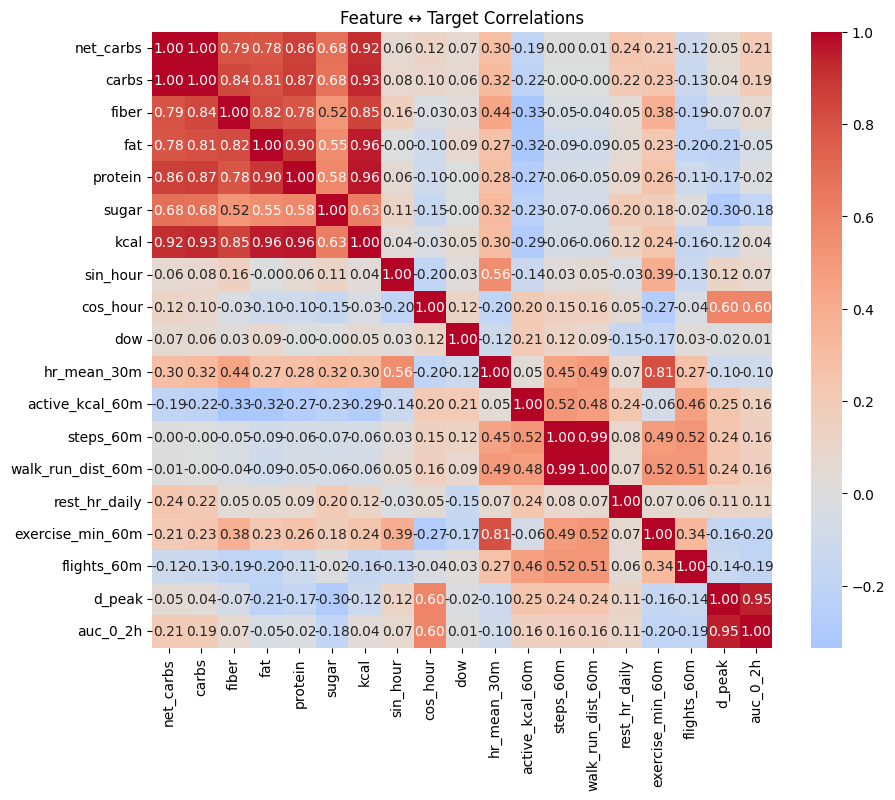

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix between features + targets
corr = df[DEFAULT_FEATURES + TARGETS].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature ↔ Target Correlations")
plt.show()


<Figure size 1000x600 with 0 Axes>

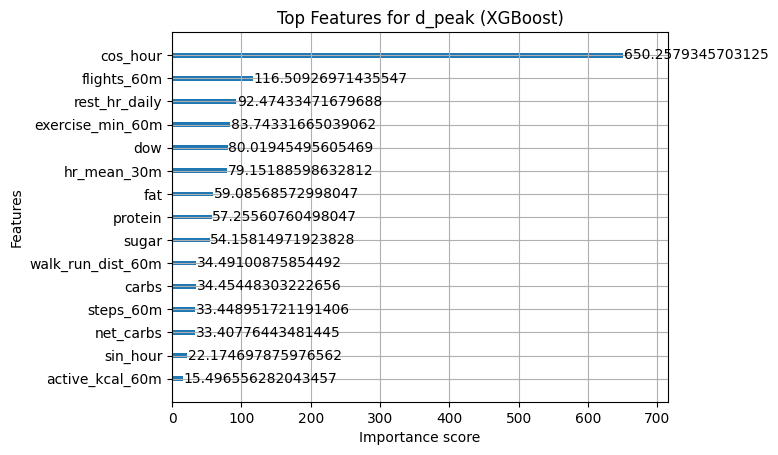

In [8]:
from xgboost import plot_importance

# Fit tree once on all train data (no split, just to inspect importance)
X, used_feats = build_feature_matrix(df, DEFAULT_FEATURES)
y = df["d_peak"].astype(float).values

tree.fit(X, y)

plt.figure(figsize=(10, 6))
plot_importance(tree, importance_type="gain", max_num_features=15)
plt.title("Top Features for d_peak (XGBoost)")
plt.show()


<Figure size 1000x600 with 0 Axes>

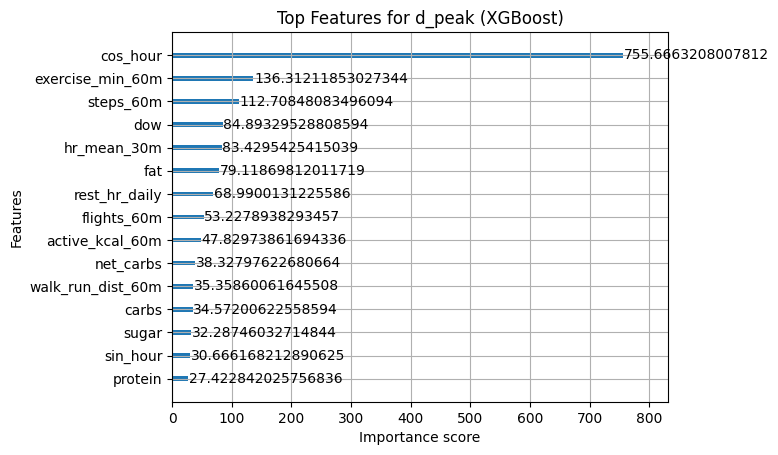

In [9]:
from xgboost import plot_importance

# Fit tree once on all train data (no split, just to inspect importance)
X, used_feats = build_feature_matrix(df, DEFAULT_FEATURES)
y = df["auc_0_2h"].astype(float).values

tree.fit(X, y)

plt.figure(figsize=(10, 6))
plot_importance(tree, importance_type="gain", max_num_features=15)
plt.title("Top Features for d_peak (XGBoost)")
plt.show()


In [10]:
import numpy as np
import pandas as pd

ds = df.sort_values("meal_time").reset_index(drop=True).copy()

# --- time since last meal (minutes) ---
# ds["time_since_last_meal_min"] = (
#     ds["meal_time"].diff().dt.total_seconds().div(60).fillna(0)
# )
# optional caps to reduce outlier leverage
# ds["time_since_last_meal_min"] = ds["time_since_last_meal_min"].clip(0, 12*60)

# --- size-normalized macros (per 100 kcal) ---
eps = 1e-6
ds["carbs_per_100kcal"]   = 100 * ds["carbs"]   / (ds["kcal"] + eps)
ds["fat_per_100kcal"]     = 100 * ds["fat"]     / (ds["kcal"] + eps)
ds["protein_per_100kcal"] = 100 * ds["protein"] / (ds["kcal"] + eps)
ds["sugar_per_100kcal"]   = 100 * ds["sugar"]   / (ds["kcal"] + eps)
ds["fiber_per_100kcal"]   = 100 * ds["fiber"]   / (ds["kcal"] + eps)

# --- composition ratios ---
ds["carb_to_fat"]     = ds["carbs"]   / (ds["fat"]     + eps)
ds["carb_to_protein"] = ds["carbs"]   / (ds["protein"] + eps)
ds["fiber_to_carb"]   = ds["fiber"]   / (ds["carbs"]   + eps)
ds["sugar_frac_carb"] = ds["sugar"]   / (ds["carbs"]   + eps)

# --- optional context history: previous meal size ---
ds["prev_meal_kcal"]  = ds["kcal"].shift(1).fillna(0)
ds["prev_meal_carbs"] = ds["carbs"].shift(1).fillna(0)
ds["prev_meal_fat"] = ds["fat"].shift(1).fillna(0)
ds["prev_meal_protein"] = ds["protein"].shift(1).fillna(0)
ds["prev_meal_fiber"] = ds["fiber"].shift(1).fillna(0)
# (optional) drop raw hour encodings to avoid shortcutting:
try:
    ds = ds.drop(columns=["sin_hour","cos_hour"])
except Exception:
    pass

ds.head(3)


,meal_id,carbohydrates,energyconsumed,fattotal,fiber,protein,sugar,meal_time,carbs,fat,...,fiber_per_100kcal,carb_to_fat,carb_to_protein,fiber_to_carb,sugar_frac_carb,prev_meal_kcal,prev_meal_carbs,prev_meal_fat,prev_meal_protein,prev_meal_fiber
0,1,95.36570,1076.849,46.8651,15.25000,75.49040,14.08500,2025-07-30 12:00:00+00:00,95.36570,46.8651,...,1.416169,2.034898,1.263282,0.159911,0.147695,0.000,0.0000,0.0000,0.0000,0.00000
1,2,39.69750,408.376,16.8392,4.27695,27.50140,15.30210,2025-07-30 13:37:00+00:00,39.69750,16.8392,...,1.047307,2.357446,1.443472,0.107739,0.385468,1076.849,95.3657,46.8651,75.4904,15.25000
2,3,63.92252,919.279,49.4770,12.62195,58.46362,25.40512,2025-07-31 11:52:00+00:00,63.92252,49.4770,...,1.373027,1.291964,1.093373,0.197457,0.397436,408.376,39.6975,16.8392,27.5014,4.27695


In [11]:
import numpy as np
import pandas as pd

def drop_correlated_features(df, target, threshold=0.8):
    """
    Drop features that are highly correlated with others,
    keeping the one more correlated with target.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must include both features and target.
    target : str
        Name of target column.
    threshold : float
        Absolute correlation above which we consider features redundant.
        
    Returns
    -------
    kept_features : list
        List of selected feature names.
    """
    corr_matrix = df.corr().abs()
    features = list(df.columns)
    features.remove(target)
    
    kept = set(features)
    
    for i, f1 in enumerate(features):
        for f2 in features[i+1:]:
            if f1 in kept and f2 in kept and corr_matrix.loc[f1, f2] > threshold:
                # Compare correlation with target
                corr1 = abs(corr_matrix.loc[f1, target])
                corr2 = abs(corr_matrix.loc[f2, target])
                if corr1 >= corr2:
                    kept.remove(f2)
                else:
                    kept.remove(f1)
    
    return list(kept)


In [12]:
selected_feats = drop_correlated_features(ds, target="d_peak", threshold=0.7)
print("Selected features:", selected_feats)

Selected features: ['fiber_to_carb', 'carbs_per_100kcal', 'steps_60m', 'active_kcal_60m', 'hour', 'fattotal', 'fiber_per_100kcal', 'auc_0_2h', 'sugar', 'exercise_min_60m', 'carb_to_protein', 'meal_id', 'prev_meal_kcal', 'dow', 'flights_60m', 'protein_per_100kcal', 'rest_hr_daily', 'base', 'sugar_frac_carb']


In [13]:
# build matrices using your existing helper
Xtr, used_feats = build_feature_matrix(train_df.merge(ds, on="meal_time", how="left"), selected_feats)
Xval, _         = build_feature_matrix(val_df.merge(ds, on="meal_time",   how="left"), used_feats)

# models (same as before)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

ridge = Pipeline([("scaler", StandardScaler()),
                  ("ridge", Ridge(alpha=1.0, random_state=42))])

tree = XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=42, n_jobs=0
)

preds_val = {}
for target in TARGETS:
    print(f"\n=== {target} (no hour, +spacing/ratios) ===")
    ytr = train_df[target].astype(float).values
    yval = val_df[target].astype(float).values

    preds_val[(target,"ridge")] = train_and_eval("Ridge", ridge, Xtr, ytr, Xval, yval)
    preds_val[(target,"tree")]  = train_and_eval("Tree",  tree,  Xtr, ytr, Xval, yval)



=== d_peak (no hour, +spacing/ratios) ===

[Ridge]  MAE=40.010  RMSE=42.072  R2=0.394

[Tree]  MAE=44.566  RMSE=51.258  R2=0.101

=== auc_0_2h (no hour, +spacing/ratios) ===

[Ridge]  MAE=28.349  RMSE=30.559  R2=0.516

[Tree]  MAE=33.699  RMSE=40.111  R2=0.166


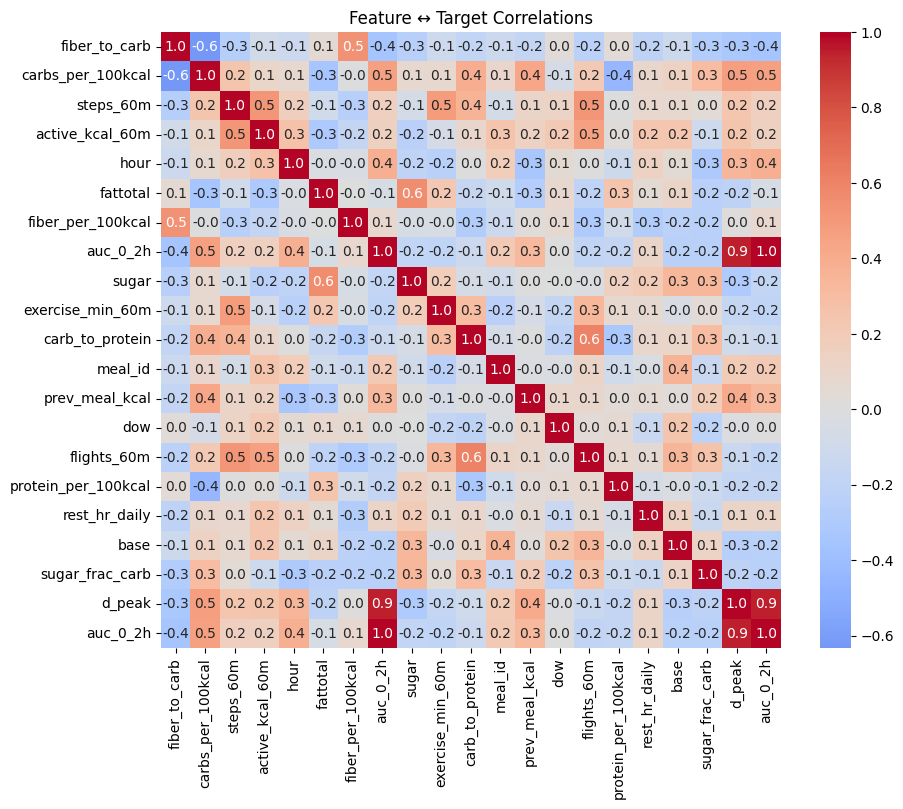

In [14]:
# Correlation matrix between features + targets
corr = ds[selected_feats + TARGETS].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".1f")
plt.title("Feature ↔ Target Correlations")
plt.show()

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ridge_importance(ridge_pipeline, feature_names, target_name):
    # grab the trained ridge model from the pipeline
    scaler = ridge_pipeline.named_steps["scaler"]
    model  = ridge_pipeline.named_steps["ridge"]

    coefs = model.coef_
    # match to features (after scaling, so coefficients are comparable)
    importance = np.abs(coefs)

    sorted_idx = np.argsort(importance)[::-1]
    top_feats  = [feature_names[i] for i in sorted_idx]
    top_coefs  = coefs[sorted_idx]

    plt.figure(figsize=(8,6))
    plt.barh(top_feats, top_coefs)
    plt.gca().invert_yaxis()
    plt.title(f"Ridge Coefficients for {target_name}")
    plt.xlabel("Coefficient value (scaled features)")
    plt.show()

# example for one target
ytr = train_df["d_peak"].astype(float).values
Xtr, used_feats = build_feature_matrix(train_df.merge(ds, on="meal_time", how="left"), NEW_FEATURES)

ridge.fit(Xtr, ytr)
plot_ridge_importance(ridge, used_feats, "d_peak")


NameError: name 'NEW_FEATURES' is not defined

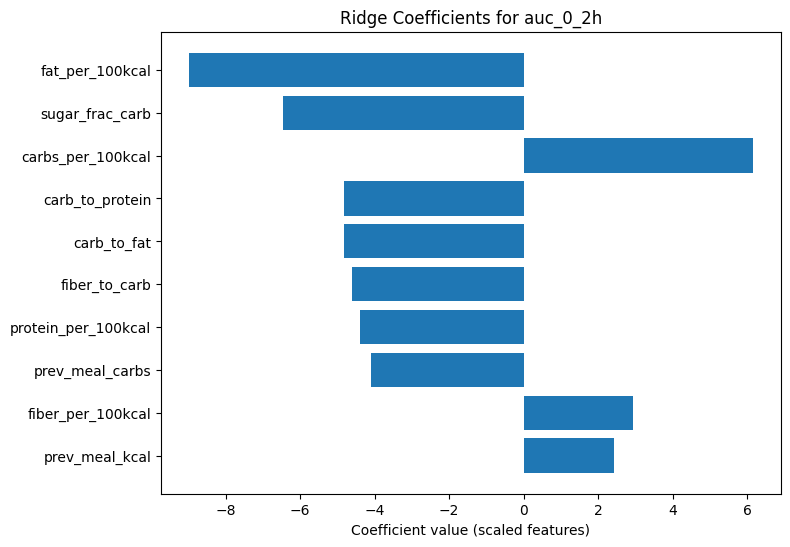

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ridge_importance(ridge_pipeline, feature_names, target_name):
    # grab the trained ridge model from the pipeline
    scaler = ridge_pipeline.named_steps["scaler"]
    model  = ridge_pipeline.named_steps["ridge"]

    coefs = model.coef_
    # match to features (after scaling, so coefficients are comparable)
    importance = np.abs(coefs)

    sorted_idx = np.argsort(importance)[::-1]
    top_feats  = [feature_names[i] for i in sorted_idx]
    top_coefs  = coefs[sorted_idx]

    plt.figure(figsize=(8,6))
    plt.barh(top_feats, top_coefs)
    plt.gca().invert_yaxis()
    plt.title(f"Ridge Coefficients for {target_name}")
    plt.xlabel("Coefficient value (scaled features)")
    plt.show()

# example for one target
ytr = train_df["auc_0_2h"].astype(float).values
Xtr, used_feats = build_feature_matrix(train_df.merge(ds, on="meal_time", how="left"), NEW_FEATURES)

ridge.fit(Xtr, ytr)
plot_ridge_importance(ridge, used_feats, "auc_0_2h")


In [16]:
PRE_MIN = 180   # minutes of CGM before meal
STEP    = 5     # minutes per step
T       = PRE_MIN // STEP  # 36


In [27]:
g5 = pd.read_csv("../data/processed/processed_glucose_5min.csv", index_col="start")
g5.index = pd.to_datetime(g5.index)   # make sure it's datetime
g5 = g5.sort_index()


In [28]:
g5.head()

,glucose_mgdl
start,
2025-07-28 23:00:00+00:00,74.93508
2025-07-28 23:05:00+00:00,83.92734
2025-07-28 23:10:00+00:00,88.92306
2025-07-28 23:15:00+00:00,95.91696
2025-07-28 23:20:00+00:00,88.92306


In [29]:
def extract_premeal_seq(g5, meal_time, T=36, step="5min"):
    start = meal_time - pd.Timedelta(minutes=T*5)
    seq = g5.loc[start:meal_time - pd.Timedelta(step), "glucose_mgdl"]
    # pad/truncate to length T
    if len(seq) < T:
        if len(seq) == 0:
            return np.full(T, np.nan)
        pad = np.full(T - len(seq), seq.iloc[0])
        seq = np.r_[pad, seq.values]
    else:
        seq = seq[-T:]
    return seq.astype(float)


In [ ]:
T = 36  # 3h of history at 5min resolution
X_seq = np.stack([extract_premeal_seq(g5, t, T) for t in ds["meal_time"]])

# handle NaNs
row_med = np.nanmedian(X_seq, axis=1, keepdims=True)
X_seq = np.where(np.isnan(X_seq), row_med, X_seq)

mu, sd = X_seq.mean(), X_seq.std() + 1e-6
X_seq_n = (X_seq - mu) / sd   # shape [N, T]

TAB_FEATURES = [
    "kcal",
    "sugar_per_100kcal",        # instead of both sugar+carb
    "prev_meal_kcal",
    "hr_mean_30m","rest_hr_daily",
    "steps_60m","dow"
]
# Tabular features
X_tab = ds[TAB_FEATURES].astype(float).fillna(0.0).values

# Targets
y_dpeak = ds["d_peak"].astype(float).values
y_auc   = ds["auc_0_2h"].astype(float).values

X_seq = np.stack([extract_premeal_seq(g5, t, T=36) for t in ds["meal_time"]])
row_med = np.nanmedian(X_seq, axis=1, keepdims=True)
X_seq = np.where(np.isnan(X_seq), row_med, X_seq)

import numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# === 1. Chronological split ===
train_df, val_df, test_df = time_split_3way(ds, val_frac=0.1, test_frac=0.2)

# === 2. Extract sequences for each split ===
def build_seq_matrix(df, g5, T=36):
    X_seq = np.stack([extract_premeal_seq(g5, t, T) for t in df["meal_time"]])
    row_med = np.nanmedian(X_seq, axis=1, keepdims=True)
    X_seq = np.where(np.isnan(X_seq), row_med, X_seq)
    return (X_seq - mu) / sd   # normalize with global mu, sd

mu, sd = X_seq.mean(), X_seq.std() + 1e-6  # from full ds

Xseq_tr = build_seq_matrix(train_df, g5, T=36)
Xseq_va = build_seq_matrix(val_df,   g5, T=36)
Xseq_te = build_seq_matrix(test_df,  g5, T=36)

# === 3. Tabular features ===
Xtab_tr = train_df[TAB_FEATURES].astype(float).fillna(0.0).values
Xtab_va = val_df[TAB_FEATURES].astype(float).fillna(0.0).values
Xtab_te = test_df[TAB_FEATURES].astype(float).fillna(0.0).values

y1_tr, y1_va, y1_te = train_df["d_peak"].values, val_df["d_peak"].values, test_df["d_peak"].values
y2_tr, y2_va, y2_te = train_df["auc_0_2h"].values, val_df["auc_0_2h"].values, test_df["auc_0_2h"].values

# === 4. Make DataLoaders ===
def make_loader(Xseq, Xtab, y1, y2, bs=32, shuffle=False):
    xseq = torch.tensor(Xseq, dtype=torch.float32).unsqueeze(-1)
    xtab = torch.tensor(Xtab, dtype=torch.float32)
    t1   = torch.tensor(y1, dtype=torch.float32)
    t2   = torch.tensor(y2, dtype=torch.float32)
    return DataLoader(TensorDataset(xseq, xtab, t1, t2),
                      batch_size=bs, shuffle=shuffle)

train_loader = make_loader(Xseq_tr, Xtab_tr, y1_tr, y2_tr, shuffle=True)
val_loader   = make_loader(Xseq_va, Xtab_va, y1_va, y2_va)
test_loader  = make_loader(Xseq_te, Xtab_te, y1_te, y2_te)


In [ ]:
# === 5. Model ===
class TinySeqEncoder(nn.Module):
    def __init__(self, d_in=1, d_model=64, nhead=4, nlayers=2, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(d_in, d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                           dropout=dropout, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=nlayers)
        self.cls = nn.Parameter(torch.zeros(1,1,d_model))
    def forward(self, x):  # x: [B,T,1]
        b = x.size(0)
        cls = self.cls.repeat(b,1,1)
        h = torch.cat([cls, self.proj(x)], dim=1)
        h = self.enc(h)
        return h[:,0]  # CLS

class MealResponseHead(nn.Module):
    def __init__(self, d_seq, d_tab, hidden=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_seq+d_tab, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden//2), nn.ReLU(),
            nn.Linear(hidden//2, 1)
        )
    def forward(self, z, xtab): return self.mlp(torch.cat([z, xtab],1)).squeeze(-1)

class FullModel(nn.Module):
    def __init__(self, seq_encoder, d_tab):
        super().__init__()
        self.seq = seq_encoder
        d_seq = self.seq(torch.zeros(1,T,1)).shape[-1]
        self.head_peak = MealResponseHead(d_seq, d_tab)
        self.head_auc  = MealResponseHead(d_seq, d_tab)
    def forward(self, xseq, xtab):
        z = self.seq(xseq)
        return self.head_peak(z,xtab), self.head_auc(z,xtab)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = FullModel(TinySeqEncoder(), d_tab=X_tab.shape[1]).to(device)


In [ ]:
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.SmoothL1Loss()  # MAE-ish and robust to outliers
def run_epoch(loader, train=True):
    model.train(train)
    tot, mae1, mae2, n = 0,0,0,0
    for xseq, xtab, t1, t2 in loader:
        xseq, xtab, t1, t2 = [d.to(device) for d in (xseq, xtab, t1, t2)]
        with torch.set_grad_enabled(train):
            p1,p2 = model(xseq,xtab)
            loss = loss_fn(p1,t1)+loss_fn(p2,t2)
        if train:
            opt.zero_grad(); loss.backward(); opt.step()
        mae1 += (p1-t1).abs().sum().item()
        mae2 += (p2-t2).abs().sum().item()
        tot  += loss.item()*len(xseq); n+=len(xseq)
    return tot/n, mae1/n, mae2/n
for ep in range(20):
    tr_loss,_,_ = run_epoch(train_loader, True)
    va_loss,m1,m2 = run_epoch(val_loader, False)
    if (ep+1)%5==0:
        print(f"ep{ep+1:02d} val_loss={va_loss:.2f} MAE Δpeak={m1:.2f} MAE AUC={m2:.2f}")

# Final test eval
test_loss,m1,m2 = run_epoch(test_loader, False)
print(f"\n=== TEST === loss={test_loss:.2f} MAE Δpeak={m1:.2f} MAE AUC={m2:.2f}")


NameError: name 'run_epoch' is not defined